# Surface factor and daily-reset RR: 2025 diagnostic

**Blinded post-result re-analysis.** 2025 was already examined for forecasting, listed-options trading and attribution. This experiment's evaluator was frozen at `dbf234d136fd291063a79e385f83c08fbb6d367b` before its own 2025 outputs were opened. The frozen RR25 M2 coefficients are reused without fitting. Rules cannot be tuned after this run.

The direct outcome is a change in decimal implied-volatility units. The secondary portfolio is an **idealised model-mid constant-factor tracking portfolio — not an executable trading result**. Its fractional options reset at each close, there are no transaction or financing costs, and the SPX hedge is frictionless. Pooled origin results overlap; all five original offsets are reported. See [protocol](../docs/surface_factor_protocol.md).

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.forecasting import DEV_START, HOLDOUT_END
from src.time_series import build_daily_time_series
from src.surface_factor_trade import (
    FROZEN_RR_SIGNAL, run_surface_factor_2025, summarize_pnl,
    offset_summary, cumulative_results,
)
EVALUATOR_COMMIT = 'dbf234d136fd291063a79e385f83c08fbb6d367b'
output = ROOT / 'data/processed/surface_factor_2025'
spx = pd.read_csv(ROOT / 'data/raw/spx_security_prices.csv', parse_dates=['date'])
spx = spx.loc[spx.date.le(HOLDOUT_END)].copy()
metrics = pd.read_csv(ROOT / 'data/processed/spx_skew_metrics_2023_2025.csv', parse_dates=['quote_date'])
metrics = metrics.loc[metrics.quote_date.between(DEV_START, HOLDOUT_END)].copy()
daily = build_daily_time_series(metrics, spx)
display(pd.Series(FROZEN_RR_SIGNAL, name='saved_model_coefficient').to_frame())

,saved_model_coefficient
intercept,0.000654
slope,-0.001725


## One frozen execution

This cell creates an exclusive manifest before generating outcomes. An existing manifest prohibits another run. It constructs the direct outcomes and streams each 2025 option date once to reconstruct production surfaces, price aged synthetic baskets and reset the exposure. All new results are saved before any old trading audit is opened. A technical failure stops this experiment.

In [2]:
result = run_surface_factor_2025(
    ROOT / 'data/raw/spx_option_prices_2025.csv', daily, spx,
    EVALUATOR_COMMIT, output, progress=True,
)
factors = result['direct_factors']
synthetic = result['synthetic_trades']
evaluated = synthetic.loc[synthetic.status.eq('evaluated')].copy()
assert json.loads((output / 'surface_factor_run.json').read_text())['status'] == 'completed'

2025-01-16: 10 surface sessions processed


2025-01-31: 20 surface sessions processed


2025-02-14: 30 surface sessions processed


2025-03-03: 40 surface sessions processed


2025-03-17: 50 surface sessions processed


...

2025-06-26: 120 surface sessions processed


2025-07-11: 130 surface sessions processed


2025-07-25: 140 surface sessions processed


2025-08-08: 150 surface sessions processed


2025-08-22: 160 surface sessions processed


## Coverage first

Factor outcomes require QC-valid 30D and 60D RR states at entry and exit. Synthetic paths additionally need supported aged strikes and a valid fresh RR basket at each rebalance. Missing paths retain their entry eligibility and failure reason; no fallback or filling is used.

In [3]:
coverage = pd.Series({
    '2025_forecast_origins': len(factors),
    'finite_nonzero_frozen_signals': int(factors.finite_nonzero_signal.sum()),
    'origins_with_full_fifth_session_endpoint': int(factors.full_exit_horizon.sum()),
    'direct_delayed_factor_available': int(factors.factor_available.sum()),
    'full_horizon_factor_available': int(factors.full_horizon_factor_pnl.notna().sum()),
    'synthetic_entry_baskets_available': int(synthetic.entry_available.sum()),
    'synthetic_complete_paths': len(evaluated),
    'synthetic_unevaluable': int(synthetic.status.eq('unevaluable').sum()),
    'synthetic_skipped': int(synthetic.status.eq('skipped').sum()),
}, name='count')
display(coverage.to_frame())
display(factors.loc[factors.factor_reason.ne(''), 'factor_reason'].value_counts().to_frame('origins'))
display(synthetic.loc[synthetic.reason.ne('')].groupby('status').reason.value_counts().to_frame('origins'))

,count
2025_forecast_origins,165
finite_nonzero_frozen_signals,162
origins_with_full_fifth_session_endpoint,160
direct_delayed_factor_available,152
full_horizon_factor_available,155
synthetic_entry_baskets_available,154
synthetic_complete_paths,145
synthetic_unevaluable,9
synthetic_skipped,11


,origins
factor_reason,
missing_qc_rr_endpoint,5
no_full_exit_horizon,5
no_signal,3


origins
status      reason                                                     
skipped     no_full_exit_horizon                                      5
            no_signal                                                 3
            entry: invalid_30d_rr25                                   2
            entry: invalid_60d_rr25                                   1
unevaluable 2025-04-04: invalid_60d_rr25                              3
            2025-04-22: invalid_30d_rr25                              3
            2025-04-10: k must lie within the sampled suppo...        2
            2025-04-11: invalid_30d_rr25                              1

## Direct factor: delayed, full horizon and first session

These are signed RR-spread changes, not option-dollar P&L. The native-coverage table reports each measure on its available dates. The decomposition then uses identical complete origins, so full-horizon = first-session + delayed interval. A negative first-session contribution can make the delay improve the result; its sign is not assumed.

In [4]:
factor_columns = ['factor_pnl', 'full_horizon_factor_pnl', 'missed_first_session']
factor_native = summarize_pnl(factors, factor_columns)
complete = factors.dropna(subset=factor_columns).copy()
factor_common = summarize_pnl(complete, factor_columns)
display(Markdown('**Native available dates**'))
display(factor_native)
display(Markdown('**Identical complete dates for the timing decomposition**'))
display(factor_common)
identity = complete.full_horizon_factor_pnl - complete.missed_first_session - complete.factor_pnl
assert identity.abs().max() < 1e-12
display(pd.Series({'max_timing_identity_error': identity.abs().max(),
                  'signed_first_session_share_of_full': complete.missed_first_session.sum() / complete.full_horizon_factor_pnl.sum()
                  if complete.full_horizon_factor_pnl.sum() != 0 else np.nan}).to_frame('value'))
factor_offsets = offset_summary(factors, ['factor_pnl'])
display(factor_offsets.drop(columns='measure').set_index('offset'))
factor_native.to_csv(output / 'factor_summary.csv', index=False)
factor_common.to_csv(output / 'factor_timing_common.csv', index=False)
factor_offsets.to_csv(output / 'factor_offsets.csv', index=False)

**Native available dates**

,measure,n,total,mean,median,positive_fraction
0,factor_pnl,152,0.012559,0.000083,0.000311,0.519737
1,full_horizon_factor_pnl,155,0.116524,0.000752,0.000956,0.612903
2,missed_first_session,154,0.099053,0.000643,0.000433,0.629870


**Identical complete dates for the timing decomposition**

,measure,n,total,mean,median,positive_fraction
0,factor_pnl,152,0.012559,0.000083,0.000311,0.519737
1,full_horizon_factor_pnl,152,0.112606,0.000741,0.000954,0.611842
2,missed_first_session,152,0.100048,0.000658,0.000447,0.638158


,value
max_timing_identity_error,0.000000
signed_first_session_share_of_full,0.888474


,n,total,mean,median,positive_fraction
offset,,,,,
0,28,0.018518,0.000661,0.000333,0.535714
1,30,0.005669,0.000189,0.000311,0.533333
2,32,0.005437,0.000170,0.000995,0.562500
3,32,-0.009686,-0.000303,-0.000271,0.468750
4,30,-0.007380,-0.000246,-0.000025,0.500000


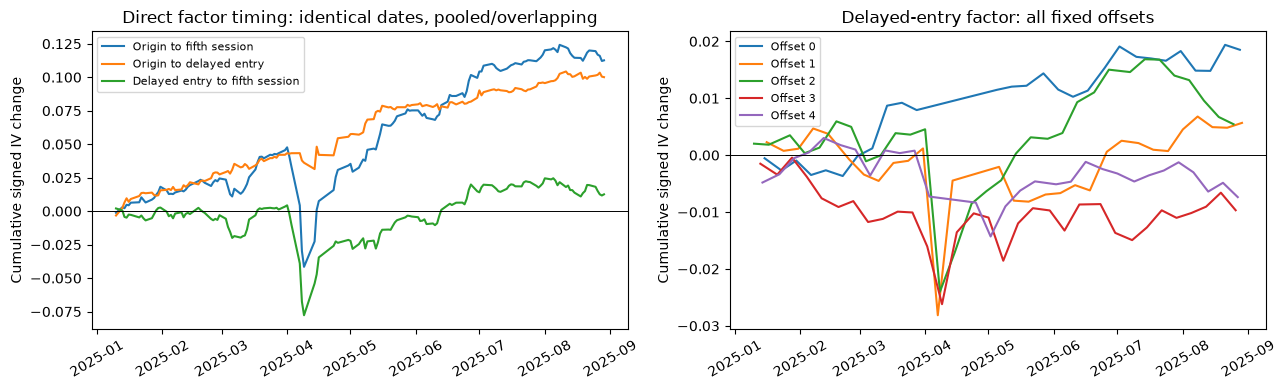

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for column, label in [('full_horizon_factor_pnl', 'Origin to fifth session'),
                      ('missed_first_session', 'Origin to delayed entry'),
                      ('factor_pnl', 'Delayed entry to fifth session')]:
    curve = cumulative_results(complete, column)
    axes[0].plot(curve.exit_date, curve.cumulative_pnl, label=label)
axes[0].set(title='Direct factor timing: identical dates, pooled/overlapping',
            ylabel='Cumulative signed IV change')
for offset in range(5):
    curve = cumulative_results(factors.loc[factors.offset.eq(offset)], 'factor_pnl')
    axes[1].plot(curve.exit_date, curve.cumulative_pnl, label=f'Offset {offset}')
axes[1].set(title='Delayed-entry factor: all fixed offsets', ylabel='Cumulative signed IV change')
for ax in axes:
    ax.axhline(0, color='black', linewidth=.7)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

## Ideal daily-reset synthetic portfolio

Each daily opening restores exact 30D/60D and signed forward 25-delta wings with gross vega one. Previous strikes and quantities earn the interval's P&L before the cash-financed replacement opens. Held options age by ACT/365 calendar days, including weekends. The previous SPX hedge earns today's price change. The option-only total is the unhedged diagnostic; no bid/ask costs or capital return are calculated.

In [6]:
portfolio_columns = ['model_option_pnl', 'hedge_pnl', 'delta_hedged_pnl']
portfolio_summary = summarize_pnl(evaluated, portfolio_columns)
portfolio_offsets = offset_summary(evaluated, portfolio_columns)
display(portfolio_summary)
display(portfolio_offsets.pivot(index='offset', columns='measure', values=['n', 'total', 'mean', 'median', 'positive_fraction']))
residuals = evaluated[['max_accounting_residual']].max()
display(residuals.to_frame('maximum'))
portfolio_summary.to_csv(output / 'portfolio_summary.csv', index=False)
portfolio_offsets.to_csv(output / 'portfolio_offsets.csv', index=False)

,measure,n,total,mean,median,positive_fraction
0,model_option_pnl,145,-0.222701,-0.001536,-0.001635,0.420690
1,hedge_pnl,145,0.220327,0.001519,0.001802,0.606897
2,delta_hedged_pnl,145,-0.002374,-0.000016,0.000114,0.558621


n                                       total  \
measure delta_hedged_pnl hedge_pnl model_option_pnl delta_hedged_pnl   
offset                                                                 
0                   29.0      29.0             29.0        -0.008332   
1                   29.0      29.0             29.0         0.005860   
2                   29.0      29.0             29.0         0.004658   
3                   29.0      29.0             29.0        -0.005594   
4                   29.0      29.0             29.0         0.001034   

                                               mean            \
measure hedge_pnl model_option_pnl delta_hedged_pnl hedge_pnl   
offset                                                          
0        0.107984        -0.116316        -0.000287  0.003724   
1        0.057171        -0.051311         0.000202  0.001971   
2        0.011581        -0.006924         0.000161  0.000399   
3        0.006358        -0.011952        -0.000193  0.000219   
4        0.037233        -0.036198         0.000036  0.001284   

                                   median                             \
measure model_option_pnl delta_hedged_pnl hedge_pnl model_option_pnl   
offset                                                                 
0              -0.004011         0.000106  0.002419        -0.003467   
1              -0.001769         0.000162  0.003203        -0.002645   
2              -0.000239         0.000363  0.001649        -0.000640   
3              -0.000412        -0.000018  0.000496        -0.000792   
4              -0.001248         0.000082 -0.000023         0.000638   

        positive_fraction                             
measure  delta_hedged_pnl hedge_pnl model_option_pnl  
offset                                                
0                0.517241  0.689655         0.310345  
1                0.586207  0.724138         0.310345  
2                0.689655  0.586207         0.448276  
3                0.482759  0.551724         0.448276  
4                0.517241  0.482759         0.586207

,maximum
max_accounting_residual,1.049508e-16


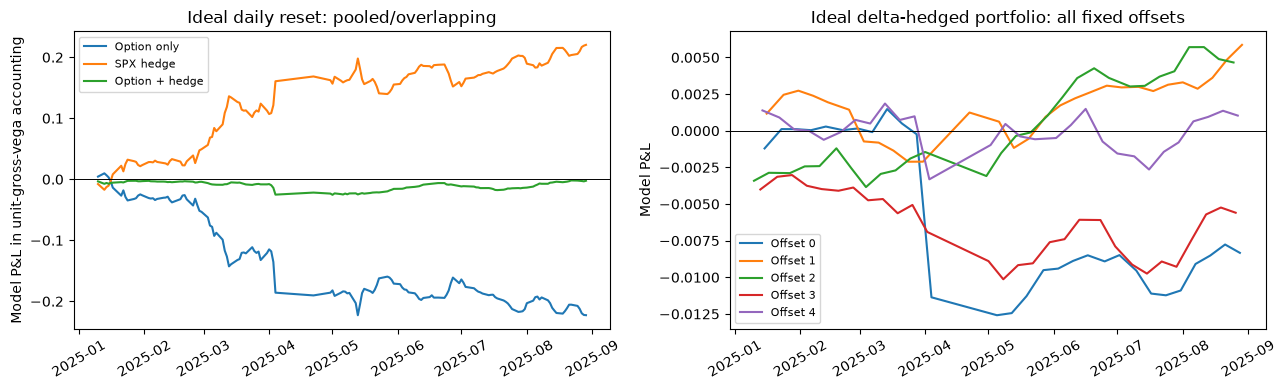

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for column, label in [('model_option_pnl', 'Option only'), ('hedge_pnl', 'SPX hedge'),
                      ('delta_hedged_pnl', 'Option + hedge')]:
    curve = cumulative_results(evaluated, column)
    axes[0].plot(curve.exit_date, curve.cumulative_pnl, label=label)
axes[0].set(title='Ideal daily reset: pooled/overlapping', ylabel='Model P&L in unit-gross-vega accounting')
for offset in range(5):
    curve = cumulative_results(evaluated.loc[evaluated.offset.eq(offset)], 'delta_hedged_pnl')
    axes[1].plot(curve.exit_date, curve.cumulative_pnl, label=f'Offset {offset}')
axes[1].set(title='Ideal delta-hedged portfolio: all fixed offsets', ylabel='Model P&L')
for ax in axes:
    ax.axhline(0, color='black', linewidth=.7)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

## Declared repricing attribution

On completed synthetic paths only, age the options with previous inputs, update forward/discount at fixed previous IV, then update held-strike IV. This fixed-order attribution reconciles option P&L; add the recorded hedge to recover total P&L. The linear held-IV term uses previous wing vegas. Its difference from exact IV repricing contains nonlinear repricing and changed sensitivity. This is explanatory allocation, not a unique causal gamma/carry attribution or a new strategy.

In [8]:
intervals = result['intervals']
intervals = intervals.loc[intervals.origin_date.isin(evaluated.origin_date)].copy()
components = ['age_repricing', 'forward_discount_repricing', 'held_iv_repricing', 'hedge_pnl', 'linear_held_iv_pnl']
attribution = intervals[components].sum().rename('total').to_frame()
attribution.loc['IV repricing minus previous-vega linear term', 'total'] = attribution.loc['held_iv_repricing', 'total'] - attribution.loc['linear_held_iv_pnl', 'total']
attribution.loc['forward/discount repricing plus hedge', 'total'] = attribution.loc['forward_discount_repricing', 'total'] + attribution.loc['hedge_pnl', 'total']
display(attribution)
assert np.isclose(intervals[['age_repricing', 'forward_discount_repricing', 'held_iv_repricing', 'hedge_pnl']].sum().sum(), evaluated.delta_hedged_pnl.sum(), atol=1e-10)
attribution.to_csv(output / 'synthetic_attribution.csv')

,total
age_repricing,-0.007983
forward_discount_repricing,-0.211915
held_iv_repricing,-0.002803
hedge_pnl,0.220327
linear_held_iv_pnl,0.007159
IV repricing minus previous-vega linear term,-0.009962
forward/discount repricing plus hedge,0.008412


## Comparison after saving the new result

The exclusive run above completed and saved all new factor and portfolio paths before this section reads the existing fixed-contract audit. These constructions have different units and available dates. The direct factor is in IV units; synthetic and listed portfolios use the project's option/hedge accounting. Daily risk resets and exposure drift mean the totals are not interchangeable return measures. A common-origin table is an availability comparison fixed in the protocol; it does not discard failed trades from their original results.

In [9]:
old = pd.read_csv(ROOT / 'data/processed/trading_locked_2025/trading_locked_2025_trades.csv', parse_dates=['origin_date'])
old = old.loc[old.status.eq('evaluated')].copy()
def comparison_table(factor_rows, synthetic_rows, listed_rows):
    return pd.DataFrame([
        {'mapping': 'Direct delayed surface factor', 'n': int(factor_rows.factor_pnl.notna().sum()),
         'total': factor_rows.factor_pnl.sum(), 'units': 'decimal IV factor change'},
        {'mapping': 'Ideal daily-reset RR, delta hedged', 'n': len(synthetic_rows),
         'total': synthetic_rows.delta_hedged_pnl.sum(), 'units': 'unit-gross-vega model P&L'},
        {'mapping': 'Fixed listed RR at midpoint, delta hedged', 'n': len(listed_rows),
         'total': listed_rows.midpoint_total_pnl.sum(), 'units': 'unit-entry-gross-vega P&L'},
        {'mapping': 'Fixed listed RR after bid/ask, delta hedged', 'n': len(listed_rows),
         'total': listed_rows.executable_total_pnl.sum(), 'units': 'unit-entry-gross-vega P&L'},
    ])
native_comparison = comparison_table(factors, evaluated, old)
display(Markdown('**Native coverage: original results retained**'))
display(native_comparison)
shared_origins = set(factors.loc[factors.factor_available, 'origin_date']) & set(evaluated.origin_date) & set(old.origin_date)
shared_comparison = comparison_table(factors.loc[factors.origin_date.isin(shared_origins)],
                                    evaluated.loc[evaluated.origin_date.isin(shared_origins)],
                                    old.loc[old.origin_date.isin(shared_origins)])
display(Markdown('**Identical available origins for the mapping diagnostic; units still differ**'))
display(shared_comparison)
native_comparison.to_csv(output / 'mapping_comparison_native.csv', index=False)
shared_comparison.to_csv(output / 'mapping_comparison_common.csv', index=False)

**Native coverage: original results retained**

,mapping,n,total,units
0,Direct delayed surface factor,152,0.012559,decimal IV factor change
1,"Ideal daily-reset RR, delta hedged",145,-0.002374,unit-gross-vega model P&L
2,"Fixed listed RR at midpoint, delta hedged",149,-0.029551,unit-entry-gross-vega P&L
3,"Fixed listed RR after bid/ask, delta hedged",149,-0.195946,unit-entry-gross-vega P&L


**Identical available origins for the mapping diagnostic; units still differ**

,mapping,n,total,units
0,Direct delayed surface factor,137,0.022340,decimal IV factor change
1,"Ideal daily-reset RR, delta hedged",137,0.002535,unit-gross-vega model P&L
2,"Fixed listed RR at midpoint, delta hedged",137,0.019728,unit-entry-gross-vega P&L
3,"Fixed listed RR after bid/ask, delta hedged",137,-0.096513,unit-entry-gross-vega P&L


## Factual interpretation

This experiment cannot replace the already-frozen headline findings. Signs, timing contributions, missing paths and accounting allocations are reported without new model selection. A positive ideal model-mid outcome alone does not establish that listed contracts can capture it after costs.

In [10]:
full = complete.full_horizon_factor_pnl.sum()
missed = complete.missed_first_session.sum()
delayed = complete.factor_pnl.sum()
ideal = evaluated.delta_hedged_pnl.sum()
held_iv = attribution.loc['held_iv_repricing', 'total']
age = attribution.loc['age_repricing', 'total']
spot_hedge = attribution.loc['forward/discount repricing plus hedge', 'total']
positive_factor_offsets = int(factor_offsets.total.gt(0).sum())
hedged_offsets = portfolio_offsets.loc[portfolio_offsets.measure.eq('delta_hedged_pnl')]
positive_ideal_offsets = int(hedged_offsets.total.gt(0).sum())
text = (
    f'On {len(complete)} complete timing origins, the direct factor totals are: full horizon **{full:+.6f}**, '
    f'first session **{missed:+.6f}**, and delayed interval **{delayed:+.6f}** decimal IV units. '
    f'The direct delayed factor is positive in {positive_factor_offsets}/5 original offsets.\n\n'
    f'The ideal daily-reset portfolio has **{ideal:+.6f}** delta-hedged model-mid P&L across '
    f'{len(evaluated)} complete paths; {positive_ideal_offsets}/5 offsets have positive totals. '
    f'Its unhedged option total is {evaluated.model_option_pnl.sum():+.6f}, and hedge contribution is '
    f'{evaluated.hedge_pnl.sum():+.6f}.\n\n'
    f'The declared allocation gives held-IV repricing {held_iv:+.6f}, calendar ageing {age:+.6f}, '
    f'and forward/discount repricing plus the hedge {spot_hedge:+.6f}. These values depend on the '
    f'fixed repricing order and do not identify a unique causal carry/convexity effect.\n\n'
)
if delayed > 0 and ideal > 0:
    text += 'The delayed factor and the ideal tracking portfolio are positive on their available samples. If the common-origin comparison retains this distinction against fixed listed contracts, it supports exposure mapping and execution as relevant differences; it does not prove an executable edge.'
elif delayed > 0:
    text += 'The delayed surface factor is positive, but the ideal option translation is not. The repricing decomposition and differing coverage show why signed constant-factor changes are insufficient to predict the full option/hedge outcome.'
else:
    text += 'The delayed factor itself is not positive on these complete timing origins. Compare its full-horizon and first-session contributions before attributing the fixed-contract outcome solely to execution or exposure drift.'
display(Markdown(text))
print('Post-result diagnostic complete. No model was refitted or tuned; no further strategy run is performed.')

On 152 complete timing origins, the direct factor totals are: full horizon **+0.112606**, first session **+0.100048**, and delayed interval **+0.012559** decimal IV units. The direct delayed factor is positive in 3/5 original offsets.

The ideal daily-reset portfolio has **-0.002374** delta-hedged model-mid P&L across 145 complete paths; 3/5 offsets have positive totals. Its unhedged option total is -0.222701, and hedge contribution is +0.220327.

The declared allocation gives held-IV repricing -0.002803, calendar ageing -0.007983, and forward/discount repricing plus the hedge +0.008412. These values depend on the fixed repricing order and do not identify a unique causal carry/convexity effect.

The delayed surface factor is positive, but the ideal option translation is not. The repricing decomposition and differing coverage show why signed constant-factor changes are insufficient to predict the full option/hedge outcome.

Post-result diagnostic complete. No model was refitted or tuned; no further strategy run is performed.
